In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from IPython.display import HTML, display
from pysam import FastaFile
from sklearn.preprocessing import LabelEncoder

In [3]:
from magneton.core_types import Protein, SubstructType
from magneton.data import SupervisedDownstreamTaskDataModule
from magneton.data.evaluations import DeepFriModule
from magneton.io.internal import filter_proteins
from magneton.models.evaluation_classifier import EvaluationClassifier
from magneton.utils import get_data_dir

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Find proteins in MF test set and in Magneton data

In [5]:
config_dir = "/home/rcalef/sandbox/repos/magneton/magneton/configs"
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            "+evaluate=deepfri",
            "output_dir='/tmp/'",
            "evaluate.model_checkpoint='/tmp'",
            "data.struct_template='/weka/scratch/weka/kellislab/rcalef/data/pdb_alphafolddb/AF-%s-F1-model_v4.pdb'",
        ],
    )
config = instantiate(cfg)
config

PipelineConfig(_target_='magneton.config.PipelineConfig', seed=42, stage='train', output_dir='/tmp/', run_id='my_new_run', data=DataConfig(_target_='magneton.config.DataConfig', data_dir='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/swissprot_subset', compression='gz', prefix='swissprot.with_ss', splits='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/dataset_splits/seq_splits.tsv', batch_size=32, fasta_path='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/sequences/uniprot_sprot.fasta.gz', labels_path='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/labels/selected_subset', struct_template='/weka/scratch/weka/kellislab/rcalef/data/pdb_alphafolddb/AF-%s-F1-model_v4.pdb', substruct_types=['Domain'], collapse_labels=False, num_loader_workers=32, model_specific_params={}), base_model=BaseModelConfig(_target_='magneton.config.BaseModelConfig', model='esmc', model_params={'model_size': '600m', 'weights_path': '/weka

In [6]:
# The following files contain the FoldSeek sequence-based clusters (AFDB50) and structure-based
# clusters (FoldSeek-Cluster), subset to only include SwissProt proteins.
interpro_dir = get_data_dir() / "interpro_103.0"
splits_dir = interpro_dir / "dataset_splits"

In [7]:
seq_splits = pd.read_table(splits_dir / "seq_splits.tsv")
seq_splits.head()

,uniprot_id,split
0,A0A009IHW8,train
1,A0A023FBW7,train
2,A0A023FDY8,train
3,A0A023FFB5,train
4,A0A023FFD0,train


In [8]:
module = SupervisedDownstreamTaskDataModule(
    data_config=config.data,
    task="GO:MF",
    data_dir=config.evaluate.data_dir,
    model_type="esmc",
)
deepfri_module = DeepFriModule(
    task="MF",
    data_dir=module.data_dir,
    struct_template=config.data.struct_template,
)
mf_df = deepfri_module.get_dataset("test").df

INFO:magneton.data.evaluations.deepfri_dataset:found PDB-UniProt mapping at: /weka/scratch/weka/kellislab/rcalef/data/magneton-data/evaluations/GeneOntology/MF.pdb_to_uniprot.tsv
INFO:magneton.data.evaluations.deepfri_dataset:downloading 1557 / 30069 missing files
100%|███████████████████████████████████████████████| 1557/1557 [00:18<00:00, 84.57it/s]
INFO:magneton.data.evaluations.utils:succesfully downloaded 0  / 1557 files
INFO:magneton.data.evaluations.utils:FASTA cache found at /weka/scratch/weka/kellislab/rcalef/data/magneton-data/evaluations/GeneOntology/MF.seqs_from_pdbs.fa


In [9]:
mf_df.head()

,protein_id,MF,labels,uniprot_id,structure_path,seq
0,11AS-A,"GO:0097367,GO:0042802,GO:0016879,GO:0032559,GO...","[tensor(466), tensor(393), tensor(288), tensor...",P00963,/weka/scratch/weka/kellislab/rcalef/data/pdb_a...,MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQD...
5,18GS-A,"GO:0030234,GO:0019899,GO:0019901,GO:0033218,GO...","[tensor(350), tensor(329), tensor(331), tensor...",P09211,/weka/scratch/weka/kellislab/rcalef/data/pdb_a...,MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...
17,1A0P-A,"GO:0140097,GO:0003677","[tensor(476), tensor(10)]",P0A8P8,/weka/scratch/weka/kellislab/rcalef/data/pdb_a...,MKQDLARIEQFLDALWLEKNLAENTLNAYRRDLSMMVEWLHHRGLT...
22,1A22-A,"GO:0005126,GO:0051427,GO:0030545,GO:0005102,GO...","[tensor(100), tensor(434), tensor(354), tensor...",P01241,/weka/scratch/weka/kellislab/rcalef/data/pdb_a...,MATGSRTSLLLAFGLLCLPWLQEGSAFPTIPLSRLFDNAMLRAHRL...
34,1A4E-A,"GO:0016209,GO:0004601,GO:0046906,GO:0016684,GO...","[tensor(196), tensor(72), tensor(410), tensor(...",P15202,/weka/scratch/weka/kellislab/rcalef/data/pdb_a...,MSKLGQEKNEVNYSDVREDRVVTNSTGNPINEPFVTQRIGEHGPLL...


In [10]:
(seq_splits.query("split == 'test'").uniprot_id.isin(mf_df.uniprot_id).value_counts())

uniprot_id
False    52801
True       328
Name: count, dtype: int64

In [11]:
want_ids = set(
    seq_splits.query("split == 'test'")
    .loc[lambda x: x.uniprot_id.isin(mf_df.uniprot_id)]
    .uniprot_id
)
len(want_ids)

328

In [12]:
prot_ds_path = get_data_dir() / "interpro_103.0" / "swissprot_subset"

In [13]:
def want_protein_id(prot: Protein) -> bool:
    return prot.uniprot_id in want_ids


selected_proteins = filter_proteins(
    prot_ds_path,
    want_protein_id,
    prefix="swissprot.with_ss",
    nprocs=32,
)
len(selected_proteins)

processing proteins: 100%|██████████████████████████████| 55/55 [00:10<00:00,  5.34it/s]


328

## Get InterPro2GO mapping

In [14]:
data_dir = get_data_dir()

go_dir = data_dir / "evaluations" / "GeneOntology"
path = go_dir / "interpro2go.txt"

go_to_interpro = defaultdict(list)
interpro_to_go = defaultdict(list)
with open(path) as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        interpro_id = line.split()[0].split(":")[-1]
        go_id = line.split(";")[-1].strip()
        go_to_interpro[go_id].append(interpro_id)
        interpro_to_go[interpro_id].append(go_id)


In [15]:
label_fname = go_dir / "nrPDB-GO_annot.tsv"
label_line = 1
with open(label_fname, "r") as f:
    all_labels = f.readlines()[label_line].strip("\n").split("\t")
labeller = LabelEncoder().fit(all_labels)
num_classes = len(labeller.classes_)
class_to_label = {go_id: i for i, go_id in enumerate(labeller.classes_.tolist())}

In [16]:
all_usable = []
for prot in selected_proteins:
    want_row = mf_df.query("uniprot_id == @prot.uniprot_id")
    if len(want_row) != 1:
        continue
    go_terms = want_row.MF.str.split(",").iat[0]

    for entry in prot.entries:
        if entry.element_type != SubstructType.DOMAIN:
            continue
        if not entry.representative:
            continue
        if entry.id not in interpro_to_go:
            continue
        for go_id in interpro_to_go[entry.id]:
            if go_id in go_terms:
                all_usable.append(
                    {
                        "uniprot_id": prot.uniprot_id,
                        "pdb_id": want_row.protein_id.iat[0],
                        "kb_id": prot.kb_id,
                        "go_id": go_id,
                        "interpro_id": entry.id,
                        "positions": entry.positions,
                    }
                )

all_usable = pd.DataFrame(all_usable)
len(all_usable)

81

In [17]:
all_usable

,uniprot_id,pdb_id,kb_id,go_id,interpro_id,positions
0,A5F384,3GBG-A,sp|A5F384|TCPN_VIBC3,GO:0003700,IPR018060,"[(172, 269)]"
1,A5F384,3GBG-A,sp|A5F384|TCPN_VIBC3,GO:0043565,IPR018060,"[(172, 269)]"
2,O08807,3VWU-A,sp|O08807|PRDX4_MOUSE,GO:0051920,IPR019479,"[(237, 264)]"
3,O43745,2BEC-A,sp|O43745|CHP2_HUMAN,GO:0005509,IPR002048,"[(26, 61), (111, 146), (152, 187)]"
4,O43927,5CBA-E,sp|O43927|CXL13_HUMAN,GO:0008009,IPR033899,"[(30, 93)]"
...,...,...,...,...,...,...
76,Q9WUN2,4JLC-A,sp|Q9WUN2|TBK1_MOUSE,GO:0004672,IPR000719,"[(9, 310)]"
77,Q9WUN2,4JLC-A,sp|Q9WUN2|TBK1_MOUSE,GO:0005524,IPR000719,"[(9, 310)]"
78,Q9Y2J8,4N2M-A,sp|Q9Y2J8|PADI2_HUMAN,GO:0005509,IPR013732,"[(1, 114)]"
79,Q9Y2J8,4N2M-A,sp|Q9Y2J8|PADI2_HUMAN,GO:0005509,IPR013733,"[(116, 274)]"


In [18]:
fasta_path = data_dir / "sequences" / "uniprot_sprot.fasta.gz"
fa = FastaFile(fasta_path)

In [19]:
fa[all_usable.kb_id.iat[0]]

'MIGKKSFQTNVYRMSKFDTYIFNNLYINDYKMFWIDSGIAKLIDKNCLVSYEINSSSIILLKKNSIQRFSLTSLSDENINVSVITISDSFIRSLKSYILGDLMIRNLYSENKDLLLWNCEHNDIAVLSEVVNGFREINYSDEFLKVFFSGFFSKVEKKYNSIFITDDLDAMEKISCLVKSDITRNWRWADICGELRTNRMILKKELESRGVKFRELINSIRISYSISLMKTGEFKIKQIAYQSGFASVSYFSTVFKSTMNVAPSEYLFMLTGVAEK'

## Prepare model

In [20]:
import esm
import torch.nn as nn
from captum.attr import Saliency
from esm.models.esmc import ESMC, ESMCOutput
from flash_attn.bert_padding import pad_input, unpad_input  # type:ignore

from magneton.data.model_specific.esmc import ESMCBatch

is_flash_attn_available = True


class ESMCForInterp(nn.Module):
    def __init__(
        self,
        oth_model: EvaluationClassifier,
    ):
        super().__init__()
        self.esmc_transformer = oth_model.base_model.model.transformer
        self.esmc_sequence_head = oth_model.base_model.model.sequence_head
        self._use_flash_attn = oth_model.base_model.model._use_flash_attn
        self.tokenizer = oth_model.base_model.model.tokenizer

        self.head = oth_model.head
        self.rep_layer = oth_model.base_model.rep_layer

        # for module in self.modules():
        # #print(type(module))
        #     if type(module) in [
        #         torch.nn.modules.normalization.LayerNorm,
        #         esm.layers.rotary.TritonRotaryEmbedding,
        #         esm.layers.blocks.SwiGLU,
        #         torch.nn.modules.activation.GELU,
        #     ]:
        #         module.rule = EpsilonRule()

    def forward(
        self,
        embeds: torch.Tensor,
    ) -> torch.Tensor:
        B, L = embeds.shape[:2]
        sequence_id = torch.ones((B, L), device=embeds.device).bool()

        # If sequence_id looks like a mask.
        if self._use_flash_attn:
            assert sequence_id.dtype == torch.bool, (
                "sequence_id must be a boolean mask if Flash Attention is used"
            )
            assert sequence_id.shape == (B, L)
            assert unpad_input is not None
            embeds, indices, *_ = unpad_input(  # type: ignore
                embeds, sequence_id
            )
        else:
            indices = None

        x, _, hiddens = self.esmc_transformer(embeds, sequence_id=sequence_id)

        if self._use_flash_attn:
            assert indices is not None
            assert pad_input is not None
            x = pad_input(x, indices, B, L)  # Back to [B, L, D]
            hiddens = [
                # Back to [[B, L, D], ...]
                pad_input(h, indices, B, L)
                for h in hiddens
            ]

        # Stack hidden states into a [n_layers, B, L, D] matrix.
        hiddens = torch.stack(hiddens, dim=0)  # type: ignore

        sequence_logits = self.esmc_sequence_head(x)
        output = ESMCOutput(
            sequence_logits=sequence_logits, embeddings=x, hidden_states=hiddens
        )
        residue_embeds = self.esmc_transformer.norm(
            output.hidden_states[self.rep_layer]
        )
        protein_embeds = residue_embeds[:, 0, :]
        return self.head.mlp(protein_embeds)


In [21]:
def tokenize(row, model):
    seq = fa[row.kb_id]
    return model.base_model.model.tokenizer(seq, return_tensors="pt")["input_ids"]


def process_one_row(row, saliency, model, return_full_scores=False):
    int_label = class_to_label[row["go_id"]]
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        tokens = tokenize(row, model).to(device)
        embeds = model.base_model.model.embed(tokens)
        attribution = saliency.attribute(embeds, target=int_label).sum(dim=-1)
    attributions = np.abs(attribution.detach().cpu().squeeze().numpy())
    attributions = (attributions - np.min(attributions)) / (
        np.max(attributions) - np.min(attributions)
    )
    attributions = attributions / attributions.sum()
    if return_full_scores:
        return attributions

    tot = 0
    for start, end in row.positions:
        # +1 for CLS token
        tot += attributions[start + 1 : end + 1].sum()
    return tot

In [22]:
models = {
    "original": "/weka/scratch/weka/kellislab/rcalef/projects/magneton/experiments/downstream_evals/esmc_300m_orig/GO:MF/final_model.ckpt",
    "domain": "/weka/scratch/weka/kellislab/rcalef/projects/magneton/experiments/downstream_evals/esmc_300m_domain_lr_default/combined_no_ft/GO:MF/final_model.ckpt",
}

In [23]:
all_score_results = []
raw_scores = []
for model_name, ckpt_path in models.items():
    model = EvaluationClassifier.load_from_checkpoint(ckpt_path)
    interp_model = ESMCForInterp(
        model,
    )
    _ = model.eval()
    _ = interp_model.eval()

    model.to(device)
    interp_model.to(device)
    saliency = Saliency(interp_model)
    all_scores = []
    this_raw_scores = []
    for _, row in all_usable.iterrows():
        all_scores.append(process_one_row(row, saliency, model))

    all_score_results.append(
        all_usable.copy().assign(
            score=all_scores,
            model=model_name,
        )
    )
all_score_results = pd.concat(all_score_results)
all_score_results.shape

INFO:magneton.models.substructure_classifier:head model: ModuleDict(
  (Domain): Sequential(
    (0): Linear(in_features=1152, out_features=1152, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1152, out_features=917, bias=True)
  )
)
INFO:magneton.models.evaluation_classifier:head model: ProteinClassificationHead(
  (mlp): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=1152, out_features=1152, bias=True)
    (2): Tanh()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=1152, out_features=489, bias=True)
  )
)
INFO:magneton.models.substructure_classifier:head model: ModuleDict(
  (Domain): Sequential(
    (0): Linear(in_features=960, out_features=960, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=960, out_features=917, bias=True)
  )
)
INFO:magneton.models.evaluation_classifier:head model: ProteinClassificationHead(
  (mlp): Sequential(
    (0):

(162, 8)

In [24]:
all_score_results.head()

,uniprot_id,pdb_id,kb_id,go_id,interpro_id,positions,score,model
0,A5F384,3GBG-A,sp|A5F384|TCPN_VIBC3,GO:0003700,IPR018060,"[(172, 269)]",0.375946,original
1,A5F384,3GBG-A,sp|A5F384|TCPN_VIBC3,GO:0043565,IPR018060,"[(172, 269)]",0.400142,original
2,O08807,3VWU-A,sp|O08807|PRDX4_MOUSE,GO:0051920,IPR019479,"[(237, 264)]",0.062702,original
3,O43745,2BEC-A,sp|O43745|CHP2_HUMAN,GO:0005509,IPR002048,"[(26, 61), (111, 146), (152, 187)]",0.523175,original
4,O43927,5CBA-E,sp|O43927|CXL13_HUMAN,GO:0008009,IPR033899,"[(30, 93)]",0.407128,original


In [25]:
orig_score = all_score_results.query("model == 'original'")

In [26]:
dom_score = all_score_results.query("model == 'domain'")

In [27]:
combined = pd.DataFrame(
    {
        "uniprot_id": orig_score.uniprot_id.tolist(),
        "go_id": orig_score.go_id.tolist(),
        "orig_score": orig_score.score.tolist(),
        "dom_score": dom_score.score.tolist(),
        "positions": orig_score.positions.tolist(),
        "kb_id": orig_score.kb_id.tolist(),
    }
).assign(
    ratio=lambda x: x.dom_score / x.orig_score,
    pct_change=lambda x: ((x.dom_score - x.orig_score) / x.orig_score)*100,
    domain_len=lambda x: x.positions.map(lambda y: sum([e-s for s,e in y])),
    tot_len=lambda x: x.kb_id.map(lambda y: len(fa[y])),
    domain_frac=lambda x: x.domain_len / x.tot_len
)

In [28]:
combined.ratio.describe()

count    81.000000
mean      1.173525
std       0.547447
min       0.440585
25%       0.894796
50%       1.088351
75%       1.254699
max       4.589131
Name: ratio, dtype: float64

In [29]:
combined["pct_change"].describe()

count     81.000000
mean      17.352539
std       54.744741
min      -55.941533
25%      -10.520382
50%        8.835093
75%       25.469867
max      358.913123
Name: pct_change, dtype: float64

Text(0.5, 1.0, 'Domain-tuning increases attribution to\nresidues in functional domains (GO:MF prediction)')

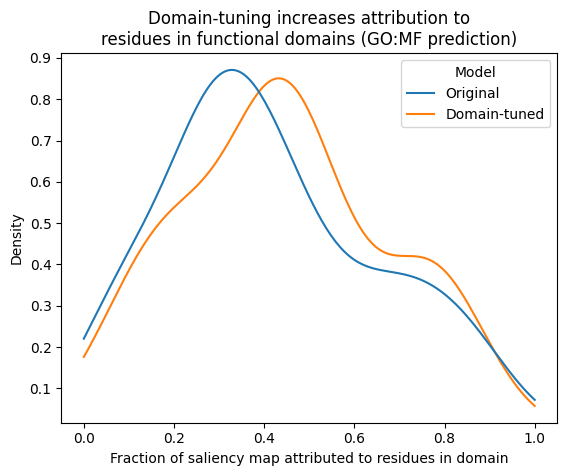

In [30]:
plot_data = all_score_results.assign(
    Model=lambda x: np.where(x.model == "original", "Original", "Domain-tuned")
)
sns.kdeplot(x="score", hue="Model", data=plot_data, clip=[0, 1])
plt.xlabel("Fraction of saliency map attributed to residues in domain")
plt.title(
    "Domain-tuning increases attribution to\nresidues in functional domains (GO:MF prediction)"
)

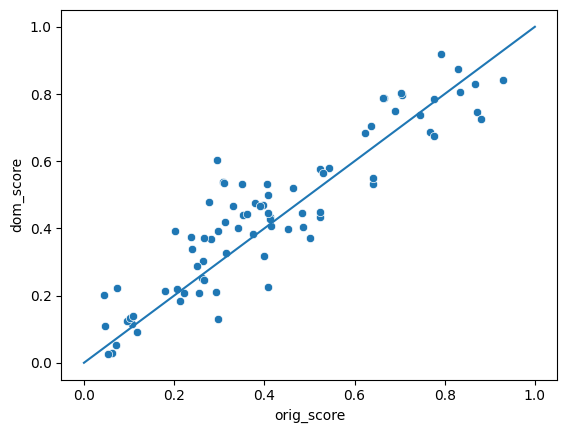

In [31]:
sns.scatterplot(x="orig_score", y="dom_score", data=combined)
plt.plot([0, 1], [0, 1])

In [32]:
all_score_results.groupby("model").score.describe()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
domain,81.0,0.444366,0.226597,0.026717,0.251298,0.434745,0.577698,0.918506
original,81.0,0.414196,0.233485,0.043874,0.260976,0.379732,0.543953,0.928460


In [33]:
combined.sort_values("pct_change", ascending=False).head(n=10)

,uniprot_id,go_id,orig_score,dom_score,positions,kb_id,ratio,pct_change,domain_len,tot_len,domain_frac
62,Q15436,GO:0008270,0.043874,0.201345,"[(58, 98)]",sp|Q15436|SC23A_HUMAN,4.589131,358.913123,40,765,0.052288
24,P06103,GO:0003723,0.072991,0.223761,"[(77, 162)]",sp|P06103|EIF3B_YEAST,3.065608,206.560754,85,763,0.111402
60,Q03532,GO:0003724,0.047403,0.108228,"[(42, 70)]",sp|Q03532|HAS1_YEAST,2.283177,128.317707,28,505,0.055446
77,Q9WUN2,GO:0005524,0.294716,0.603657,"[(9, 310)]",sp|Q9WUN2|TBK1_MOUSE,2.048267,104.826686,301,729,0.412894
72,Q9ULC6,GO:0005509,0.201299,0.392383,"[(1, 113)]",sp|Q9ULC6|PADI1_HUMAN,1.949259,94.925873,112,663,0.168929
54,P53742,GO:0005525,0.308721,0.536912,"[(212, 373)]",sp|P53742|NOG2_YEAST,1.739152,73.915160,161,486,0.331276
76,Q9WUN2,GO:0004672,0.310925,0.534248,"[(9, 310)]",sp|Q9WUN2|TBK1_MOUSE,1.718252,71.825170,301,729,0.412894
27,P09234,GO:0008270,0.277788,0.477251,"[(1, 38)]",sp|P09234|RU1C_HUMAN,1.718041,71.804096,37,159,0.232704
37,P11875,GO:0005524,0.236769,0.375114,"[(1, 87)]",sp|P11875|SYR_ECOLI,1.584302,58.430179,86,577,0.149047
67,Q93VD3,GO:0005524,0.350475,0.532062,"[(31, 286)]",sp|Q93VD3|CIPKN_ARATH,1.518119,51.811942,255,482,0.529046


In [34]:
want_row = all_usable.query("uniprot_id == 'Q15436' and go_id == 'GO:0008270'").iloc[0]
want_row

uniprot_id                    Q15436
pdb_id                        2NUP-A
kb_id          sp|Q15436|SC23A_HUMAN
go_id                     GO:0008270
interpro_id                IPR006895
positions                 [(58, 98)]
Name: 62, dtype: object

In [35]:
example_attributions = {}
for model_name, ckpt_path in models.items():
    model = EvaluationClassifier.load_from_checkpoint(ckpt_path)
    interp_model = ESMCForInterp(
        model,
    )
    _ = model.eval()
    _ = interp_model.eval()

    model.to(device)
    interp_model.to(device)
    saliency = Saliency(interp_model)
    example_attributions[model_name] = process_one_row(
        want_row,
        saliency,
        model,
        return_full_scores=True,
    )

INFO:magneton.models.substructure_classifier:head model: ModuleDict(
  (Domain): Sequential(
    (0): Linear(in_features=1152, out_features=1152, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1152, out_features=917, bias=True)
  )
)
INFO:magneton.models.evaluation_classifier:head model: ProteinClassificationHead(
  (mlp): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=1152, out_features=1152, bias=True)
    (2): Tanh()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=1152, out_features=489, bias=True)
  )
)
INFO:magneton.models.substructure_classifier:head model: ModuleDict(
  (Domain): Sequential(
    (0): Linear(in_features=960, out_features=960, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=960, out_features=917, bias=True)
  )
)
INFO:magneton.models.evaluation_classifier:head model: ProteinClassificationHead(
  (mlp): Sequential(
    (0):

In [36]:
want_row

uniprot_id                    Q15436
pdb_id                        2NUP-A
kb_id          sp|Q15436|SC23A_HUMAN
go_id                     GO:0008270
interpro_id                IPR006895
positions                 [(58, 98)]
Name: 62, dtype: object

In [37]:
start = 58
end = 98

In [38]:
tokens = tokenize(want_row, model)

In [39]:
attributions = example_attributions["original"][1:-1]
attributions = (attributions - np.min(attributions)) / (np.max(attributions) - np.min(attributions))
words = model.base_model.model.tokenizer.batch_decode(tokens)[0].split()[1:-1]

html_output = ""
for i, (word, attr) in enumerate(zip(words, attributions)):
    if word == "<cls>":
        word = "[CLS]"
    if word == "<eos>":
        word = "[EOS]"

    # Using a simple red color scale for positive attributions
    # You would typically handle positive/negative attributions differently
    color_intensity = int(attr * 255)
    if i == start:
        html_output += '<span style="background-color: rgba(0, 200, 0, 0.5); padding: 2px;">[DOM_START]</span> '
    if i == end:
        html_output += '<span style="background-color: rgba(0, 200, 0, 0.5); padding: 2px;">[DOM_END]</span> '

    html_output += f'<span style="background-color: rgba(255, 0, 0, {attr}); padding: 2px;">{word}</span> '


# Display in a Jupyter notebook
display(HTML(html_output))

In [40]:
print(html_output)

<span style="background-color: rgba(255, 0, 0, 0.4573954939842224); padding: 2px;">M</span> <span style="background-color: rgba(255, 0, 0, 0.17840072512626648); padding: 2px;">T</span> <span style="background-color: rgba(255, 0, 0, 0.11346837133169174); padding: 2px;">T</span> <span style="background-color: rgba(255, 0, 0, 0.16772602498531342); padding: 2px;">Y</span> <span style="background-color: rgba(255, 0, 0, 0.19604633748531342); padding: 2px;">L</span> <span style="background-color: rgba(255, 0, 0, 0.1327817142009735); padding: 2px;">E</span> <span style="background-color: rgba(255, 0, 0, 0.2177373766899109); padding: 2px;">F</span> <span style="background-color: rgba(255, 0, 0, 0.16990599036216736); padding: 2px;">I</span> <span style="background-color: rgba(255, 0, 0, 0.06583575159311295); padding: 2px;">Q</span> <span style="background-color: rgba(255, 0, 0, 0.06451688706874847); padding: 2px;">Q</span> <span style="background-color: rgba(255, 0, 0, 0.11596350371837616); padd

In [41]:
attributions = example_attributions["domain"][1:-1]
attributions = (attributions - np.min(attributions)) / (np.max(attributions) - np.min(attributions))
words = model.base_model.model.tokenizer.batch_decode(tokens)[0].split()[1:-1]

html_output = ""
for i, (word, attr) in enumerate(zip(words, attributions)):
    if word == "<cls>":
        word = "[CLS]"
    if word == "<eos>":
        word = "[EOS]"

    # Using a simple red color scale for positive attributions
    # You would typically handle positive/negative attributions differently
    color_intensity = int(attr * 255)
    if i == start:
        html_output += '<span style="background-color: rgba(0, 200, 0, 0.5); padding: 2px;">[DOM_START]</span> '
    if i == end:
        html_output += '<span style="background-color: rgba(0, 200, 0, 0.5); padding: 2px;">[DOM_END]</span> '
    html_output += f'<span style="background-color: rgba(255, 0, 0, {attr}); padding: 2px;">{word}</span> '

# Display in a Jupyter notebook
display(HTML(html_output))

In [42]:
print(html_output)

<span style="background-color: rgba(255, 0, 0, 1.0); padding: 2px;">M</span> <span style="background-color: rgba(255, 0, 0, 0.14507271349430084); padding: 2px;">T</span> <span style="background-color: rgba(255, 0, 0, 0.10742092877626419); padding: 2px;">T</span> <span style="background-color: rgba(255, 0, 0, 0.15526774525642395); padding: 2px;">Y</span> <span style="background-color: rgba(255, 0, 0, 0.11824966222047806); padding: 2px;">L</span> <span style="background-color: rgba(255, 0, 0, 0.09140048176050186); padding: 2px;">E</span> <span style="background-color: rgba(255, 0, 0, 0.1119338646531105); padding: 2px;">F</span> <span style="background-color: rgba(255, 0, 0, 0.13006220757961273); padding: 2px;">I</span> <span style="background-color: rgba(255, 0, 0, 0.04619883745908737); padding: 2px;">Q</span> <span style="background-color: rgba(255, 0, 0, 0.04792756587266922); padding: 2px;">Q</span> <span style="background-color: rgba(255, 0, 0, 0.07104422897100449); padding: 2px;">N</